# Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Imports

In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

MODELS_DIR = '/content/drive/MyDrive/DMIF/models'
print("Looking in:", MODELS_DIR)

Looking in: /content/drive/MyDrive/DMIF/models


# Load All Results

In [ ]:
lstm_variants = ['baseline', 'bilstm', 'attention', 'gru']
cnn_combos    = [
    ('efficientnet', 'candlestick'),
    ('mobilenet',    'candlestick'),
    ('efficientnet', 'heatmap'),
    ('mobilenet',    'heatmap'),
]

def load_json(path):
    if not os.path.exists(path):
        print(f"  MISSING: {path}")
        return None
    with open(path) as f:
        return json.load(f)

lstm_results = {}
for v in lstm_variants:
    path = f'{MODELS_DIR}/{v}_results.json'
    r = load_json(path)
    if r:
        lstm_results[v] = r

cnn_results = {}
for model_type, chart_type in cnn_combos:
    key  = f'{model_type}_{chart_type}'
    path = f'{MODELS_DIR}/cnn_{model_type}_{chart_type}_results.json'
    r = load_json(path)
    if r:
        cnn_results[key] = r

print(f"\nLoaded {len(lstm_results)}/4 LSTM results")
print(f"Loaded {len(cnn_results)}/4 CNN results")


Loaded 4/4 LSTM results
Loaded 4/4 CNN results


# LSTM Comparison Table

In [ ]:
lstm_rows = []
for name, r in lstm_results.items():
    lstm_rows.append({
        'Model'        : name,
        'Test Acc'     : r['test_accuracy'],
        'Precision(UP)': r['precision_up'],
        'Recall(UP)'   : r['recall_up'],
        'F1(UP)'       : r['f1_score_up'],
        'ROC-AUC'      : r['roc_auc'],
        'Best Thresh'  : r['best_threshold'],
    })

lstm_df = pd.DataFrame(lstm_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("=== LSTM VARIANTS — sorted by ROC-AUC ===\n")
print(lstm_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== LSTM VARIANTS — sorted by ROC-AUC ===

    Model  Test Acc  Precision(UP)  Recall(UP)  F1(UP)  ROC-AUC  Best Thresh
   bilstm    0.5686         0.4087      0.3835  0.3957   0.5471       0.5100
 baseline    0.5728         0.4114      0.3712  0.3902   0.5467       0.5200
attention    0.5658         0.4052      0.3824  0.3935   0.5438       0.4800
      gru    0.5779         0.4095      0.3300  0.3655   0.5438       0.5300


# CNN Comparison Table

In [ ]:
cnn_rows = []
for name, r in cnn_results.items():
    cnn_rows.append({
        'Model'        : f"{r['model_type']} / {r['chart_type']}",
        'Test Acc'     : r['test_accuracy'],
        'Precision(UP)': r['precision_up'],
        'Recall(UP)'   : r['recall_up'],
        'F1(UP)'       : r['f1_score_up'],
        'ROC-AUC'      : r['roc_auc'],
        'Best Thresh'  : r['best_threshold'],
    })

cnn_df = pd.DataFrame(cnn_rows).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print("=== CNN COMBINATIONS — sorted by ROC-AUC ===\n")
print(cnn_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

=== CNN COMBINATIONS — sorted by ROC-AUC ===

                     Model  Test Acc  Precision(UP)  Recall(UP)  F1(UP)  ROC-AUC  Best Thresh
   mobilenet / candlestick    0.5595         0.3834      0.4323  0.4063   0.5460       0.5000
efficientnet / candlestick    0.6513         0.0000      0.0000  0.0000   0.5258       0.5000
       mobilenet / heatmap    0.5620         0.3776      0.2828  0.3234   0.5088       0.5000
    efficientnet / heatmap    0.6299         0.0000      0.0000  0.0000   0.4980       0.4900


# Select Best LSTM and Best CNN
Ranked primarily by ROC-AUC (threshold-independent — the fairest measure of genuine learned signal), with F1 as tiebreaker.

In [ ]:
best_lstm_name = lstm_df.iloc[0]['Model']
best_lstm_auc  = lstm_df.iloc[0]['ROC-AUC']
best_lstm_f1   = lstm_df.iloc[0]['F1(UP)']

best_cnn_name  = cnn_df.iloc[0]['Model']
best_cnn_auc   = cnn_df.iloc[0]['ROC-AUC']
best_cnn_f1    = cnn_df.iloc[0]['F1(UP)']

print("="*55)
print("BEST LSTM VARIANT")
print("="*55)
print(f"  Variant : {best_lstm_name}")
print(f"  ROC-AUC : {best_lstm_auc:.4f}")
print(f"  F1 (UP) : {best_lstm_f1:.4f}")

print()
print("="*55)
print("BEST CNN COMBINATION")
print("="*55)
print(f"  Combo   : {best_cnn_name}")
print(f"  ROC-AUC : {best_cnn_auc:.4f}")
print(f"  F1 (UP) : {best_cnn_f1:.4f}")
print("="*55)

BEST LSTM VARIANT
  Variant : bilstm
  ROC-AUC : 0.5471
  F1 (UP) : 0.3957

BEST CNN COMBINATION
  Combo   : mobilenet / candlestick
  ROC-AUC : 0.5460
  F1 (UP) : 0.4063


# Visual Comparison — ROC-AUC and F1 side by side

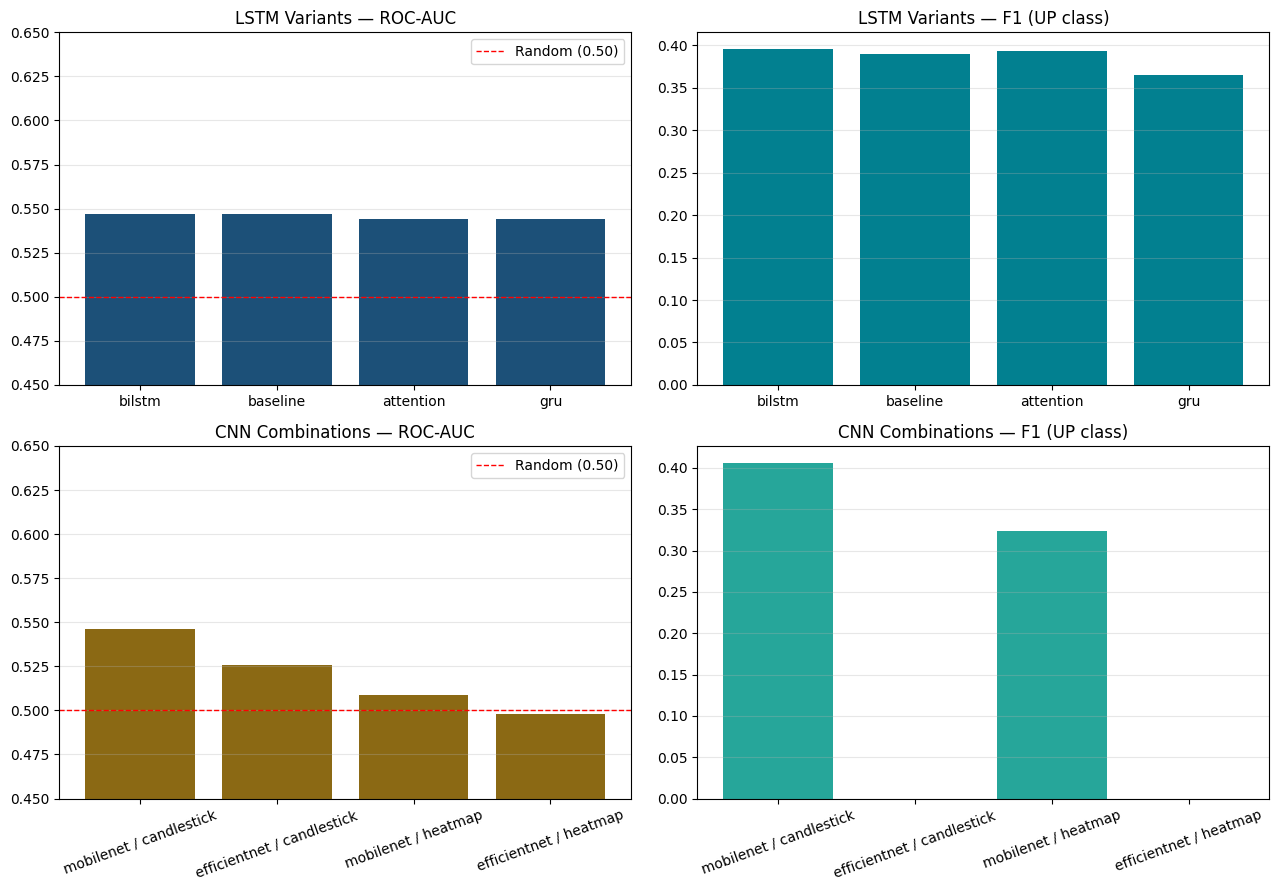

Saved: /content/drive/MyDrive/DMIF/models/model_comparison.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# LSTM ROC-AUC
axes[0,0].bar(lstm_df['Model'], lstm_df['ROC-AUC'], color='#1C5078')
axes[0,0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random (0.50)')
axes[0,0].set_title('LSTM Variants — ROC-AUC')
axes[0,0].set_ylim(0.45, max(0.65, lstm_df['ROC-AUC'].max()+0.05))
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# LSTM F1
axes[0,1].bar(lstm_df['Model'], lstm_df['F1(UP)'], color='#028090')
axes[0,1].set_title('LSTM Variants — F1 (UP class)')
axes[0,1].grid(axis='y', alpha=0.3)

# CNN ROC-AUC
axes[1,0].bar(cnn_df['Model'], cnn_df['ROC-AUC'], color='#8B6914')
axes[1,0].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random (0.50)')
axes[1,0].set_title('CNN Combinations — ROC-AUC')
axes[1,0].set_ylim(0.45, max(0.65, cnn_df['ROC-AUC'].max()+0.05))
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].legend()
axes[1,0].grid(axis='y', alpha=0.3)

# CNN F1
axes[1,1].bar(cnn_df['Model'], cnn_df['F1(UP)'], color='#26A69A')
axes[1,1].set_title('CNN Combinations — F1 (UP class)')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plot_path = f'{MODELS_DIR}/model_comparison.png'
plt.savefig(plot_path, dpi=120)
plt.show()
print(f"Saved: {plot_path}")

# Save Comparison Summary

In [ ]:
summary = {
    'lstm_ranking' : lstm_df.to_dict(orient='records'),
    'cnn_ranking'  : cnn_df.to_dict(orient='records'),
    'best_lstm'    : {
        'name'    : best_lstm_name,
        'roc_auc' : float(best_lstm_auc),
        'f1_up'   : float(best_lstm_f1),
    },
    'best_cnn'     : {
        'name'    : best_cnn_name,
        'roc_auc' : float(best_cnn_auc),
        'f1_up'   : float(best_cnn_f1),
    }
}

summary_path = f'{MODELS_DIR}/model_comparison_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"Comparison summary saved: {summary_path}")
print()
print(json.dumps(summary, indent=2))
print()
print("="*55)
print(f"NEXT STEP: Build the Fusion Layer using")
print(f"  Best LSTM : {best_lstm_name}")
print(f"  Best CNN  : {best_cnn_name}")
print("="*55)

Comparison summary saved: /content/drive/MyDrive/DMIF/models/model_comparison_summary.json

{
  "lstm_ranking": [
    {
      "Model": "bilstm",
      "Test Acc": 0.5686115949241105,
      "Precision(UP)": 0.4087390873908739,
      "Recall(UP)": 0.38350785340314136,
      "F1(UP)": 0.39572169215353115,
      "ROC-AUC": 0.5470757795214539,
      "Best Thresh": 0.5100000000000002
    },
    {
      "Model": "baseline",
      "Test Acc": 0.5727792983329186,
      "Precision(UP)": 0.4113710809546093,
      "Recall(UP)": 0.3711788549231549,
      "F1(UP)": 0.3902428197274382,
      "ROC-AUC": 0.5467381977965085,
      "Best Thresh": 0.5200000000000002
    },
    {
      "Model": "attention",
      "Test Acc": 0.5658279422741975,
      "Precision(UP)": 0.4052445518414105,
      "Recall(UP)": 0.38236784326971796,
      "F1(UP)": 0.3934739631987139,
      "ROC-AUC": 0.5438492807938696,
      "Best Thresh": 0.48000000000000015
    },
    {
      "Model": "gru",
      "Test Acc": 0.5779267230654